# Task 4 — Evaluate Model Performance Using Different Activation Functions
Train the **same architecture** 3 times using `ReLU`, `Sigmoid`, and `Tanh`.
Compare test accuracy, loss, and training curves side by side.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Load & Prepare Data

In [4]:
df = pd.read_csv('datasets/house_prices.csv')

median_price = df['price'].median()

df['price_category'] = (df['price'] >= median_price).astype(int)

X = df[['sqft_living', 'bedrooms']].values

y = df['price_category'].values

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 17290 | Test: 4323


## 2. Model Builder Function

In [5]:
def build_model(activation, name):
    """Same architecture, different hidden activation."""
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation=activation),
        layers.Dense(16, activation=activation),
        layers.Dense(1,  activation='sigmoid'),
    ], name=name)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Model builder ready.')

Model builder ready.


## 3. Train All Three Activation Functions

In [6]:
ACTIVATIONS = ['relu', 'sigmoid', 'tanh']
EPOCHS      = 60
results     = {}

for act in ACTIVATIONS:
    print(f'\n--- Training: {act.upper()} ---')
    model = build_model(activation=act, name=f'model_{act}')
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[act] = {'model': model, 'history': history,
                    'test_acc': acc, 'test_loss': loss}
    print(f'  Test Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}')


--- Training: RELU ---
  Test Accuracy: 72.47%  |  Test Loss: 0.5292

--- Training: SIGMOID ---
  Test Accuracy: 72.33%  |  Test Loss: 0.5326

--- Training: TANH ---
  Test Accuracy: 72.61%  |  Test Loss: 0.5296


## 4. Summary Table

In [7]:
summary = pd.DataFrame({
    'Activation':   [a.upper() for a in ACTIVATIONS],
    'Test Accuracy': [f"{results[a]['test_acc']*100:.2f}%" for a in ACTIVATIONS],
    'Test Loss':     [f"{results[a]['test_loss']:.4f}"    for a in ACTIVATIONS],
    'Final Train Acc': [f"{results[a]['history'].history['accuracy'][-1]*100:.2f}%" for a in ACTIVATIONS],
    'Final Val Acc':   [f"{results[a]['history'].history['val_accuracy'][-1]*100:.2f}%" for a in ACTIVATIONS],
})
summary

,Activation,Test Accuracy,Test Loss,Final Train Acc,Final Val Acc
0,RELU,72.47%,0.5292,72.63%,71.20%
1,SIGMOID,72.33%,0.5326,72.88%,71.20%
2,TANH,72.61%,0.5296,72.65%,71.49%


## 5. Plot — Training Accuracy per Activation

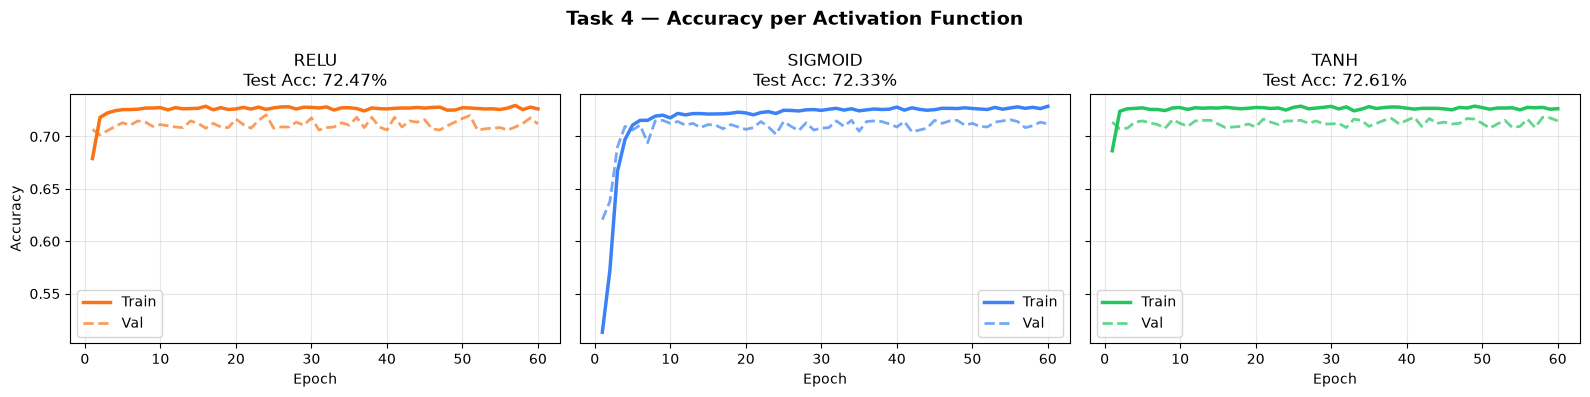

In [8]:
COLORS = {'relu': '#f97316', 'sigmoid': '#3b82f6', 'tanh': '#22c55e'}
epochs_x = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, act in enumerate(ACTIVATIONS):
    h = results[act]['history'].history
    ax = axes[i]
    ax.plot(epochs_x, h['accuracy'],     color=COLORS[act], lw=2.5, label='Train')
    ax.plot(epochs_x, h['val_accuracy'], color=COLORS[act], lw=2,   ls='--', alpha=0.7, label='Val')
    ax.set_title(f'{act.upper()}\nTest Acc: {results[act]["test_acc"]*100:.2f}%', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy' if i == 0 else '')
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Task 4 — Accuracy per Activation Function', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Plot — Training Loss per Activation

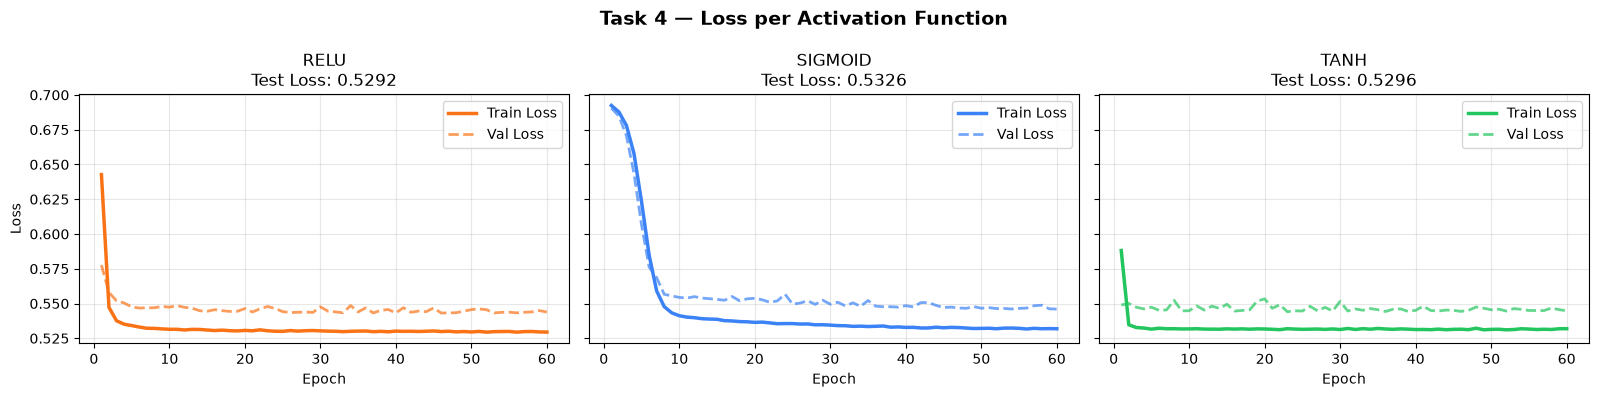

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, act in enumerate(ACTIVATIONS):
    h = results[act]['history'].history
    ax = axes[i]
    ax.plot(epochs_x, h['loss'],     color=COLORS[act], lw=2.5, label='Train Loss')
    ax.plot(epochs_x, h['val_loss'], color=COLORS[act], lw=2,   ls='--', alpha=0.7, label='Val Loss')
    ax.set_title(f'{act.upper()}\nTest Loss: {results[act]["test_loss"]:.4f}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss' if i == 0 else '')
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Task 4 — Loss per Activation Function', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Plot — Bar Chart: Final Test Accuracy

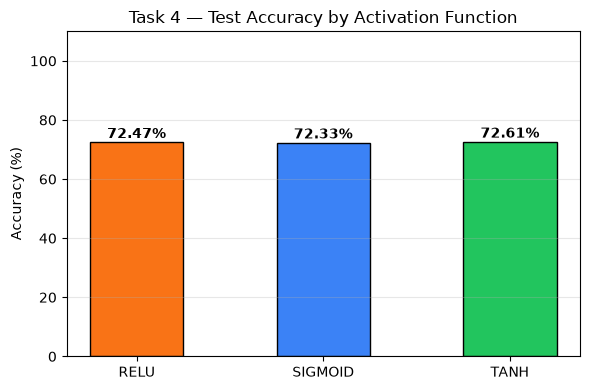

In [10]:
acts  = [a.upper() for a in ACTIVATIONS]
accs  = [results[a]['test_acc'] * 100 for a in ACTIVATIONS]
colors = [COLORS[a] for a in ACTIVATIONS]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(acts, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title('Task 4 — Test Accuracy by Activation Function', fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()